In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/t-train.csv")
test_df = pd.read_csv("/content/t-test.csv")

print("TRAIN:", train_df.shape)
print("TEST:", test_df.shape)

TRAIN: (6375, 15)
TEST: (1608, 15)


In [ ]:
# Ver información general
print("TRAIN")
train_df.info()

print("\nTEST")
test_df.info() #Comprobar cuales quedaron como nuemricas y categoricas

TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6375 entries, 0 to 6374
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    6375 non-null   object 
 1   Age                        6375 non-null   int64  
 2   Gender                     6375 non-null   object 
 3   User_Archetype             6375 non-null   object 
 4   Primary_Platform           6375 non-null   object 
 5   Daily_Screen_Time_Hours    6375 non-null   float64
 6   Dominant_Content_Type      6375 non-null   object 
 7   Activity_Type              6375 non-null   object 
 8   Late_Night_Usage           6375 non-null   bool   
 9   Social_Comparison_Trigger  6375 non-null   bool   
 10  Sleep_Duration_Hours       6375 non-null   float64
 11  GAD_7_Score                6375 non-null   int64  
 12  GAD_7_Severity             6375 non-null   object 
 13  PHQ_9_Score                6375 non-null  

In [ ]:
# Variable objetivo: nivel de ansiedad
y_train = train_df["GAD_7_Severity"]
y_test = test_df["GAD_7_Severity"]


columnas_eliminar = [
    "User_ID",
    "GAD_7_Severity",
    "GAD_7_Score",
    "PHQ_9_Score",
    "PHQ_9_Severity"
]

X_train = train_df.drop(columns=columnas_eliminar)
X_test = test_df.drop(columns=columnas_eliminar)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nVariables utilizadas:")
print(X_train.columns.tolist())

X_train: (6375, 10)
X_test: (1608, 10)

Variables utilizadas:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_features)

Variables categóricas:
['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

resultados_cv = []

for profundidad in [2, 3, 4, 5, 6, 7, 8, 10]:

    tree_cv = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=46,
        class_weight="balanced"
    )

    model_cv = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", tree_cv)
        ]
    )

    scores = cross_val_score(
        model_cv,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro"
    )

    resultados_cv.append({
        "max_depth": profundidad,
        "f1_macro_promedio": scores.mean(),
        "desviacion": scores.std()
    })

resultados_cv_df = pd.DataFrame(resultados_cv)

resultados_cv_df

,max_depth,f1_macro_promedio,desviacion
0,2,0.527742,0.024219
1,3,0.507716,0.013868
2,4,0.508482,0.012434
3,5,0.494544,0.014239
4,6,0.490388,0.016622
5,7,0.473801,0.016089
6,8,0.463726,0.013695
7,10,0.463986,0.011767


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

final_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=46,
    class_weight="balanced"
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", final_tree)
    ]
)

# Entrenamos con todo TRAIN
final_model.fit(X_train, y_train)

# Predecimos sobre TEST
y_pred = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy (%): {accuracy * 100:.2f}%")
print(f"F1 Macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Accuracy: 0.5715
Accuracy (%): 57.15%
F1 Macro: 0.5303

Classification Report:
              precision    recall  f1-score   support

        MILD       0.52      0.45      0.48       571
     MINIMAL       0.68      0.68      0.68       466
    MODERATE       0.54      0.70      0.61       441
      SEVERE       0.47      0.28      0.35       130

    accuracy                           0.57      1608
   macro avg       0.55      0.53      0.53      1608
weighted avg       0.57      0.57      0.56      1608




El modelo final de GAD-7 obtuvo un accuracy del 57.15% y un F1 Macro de 0.53. El mejor rendimiento se observó en las categorías Minimal y Moderate, mientras que la clasificación de Mild y especialmente Severe fue más limitada.
---



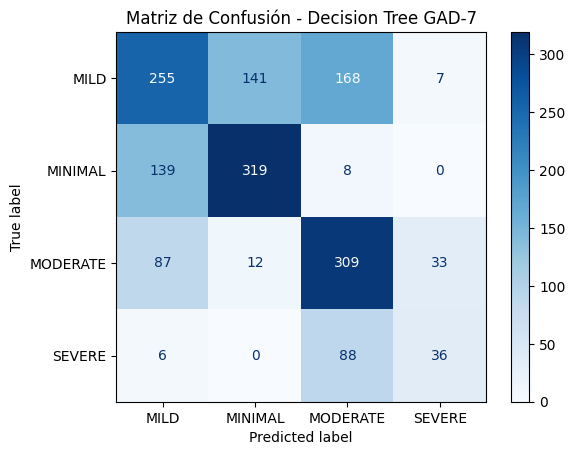

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Decision Tree GAD-7")
plt.show()

La matriz de confusión muestra que el modelo distingue relativamente bien las categorías Minimal y Moderate, pero presenta mayor dificultad con Mild y Severe. En particular, muchos casos Severe son clasificados como Moderate, lo que indica que el árbol tiene dificultades para separar niveles cercanos de severidad.

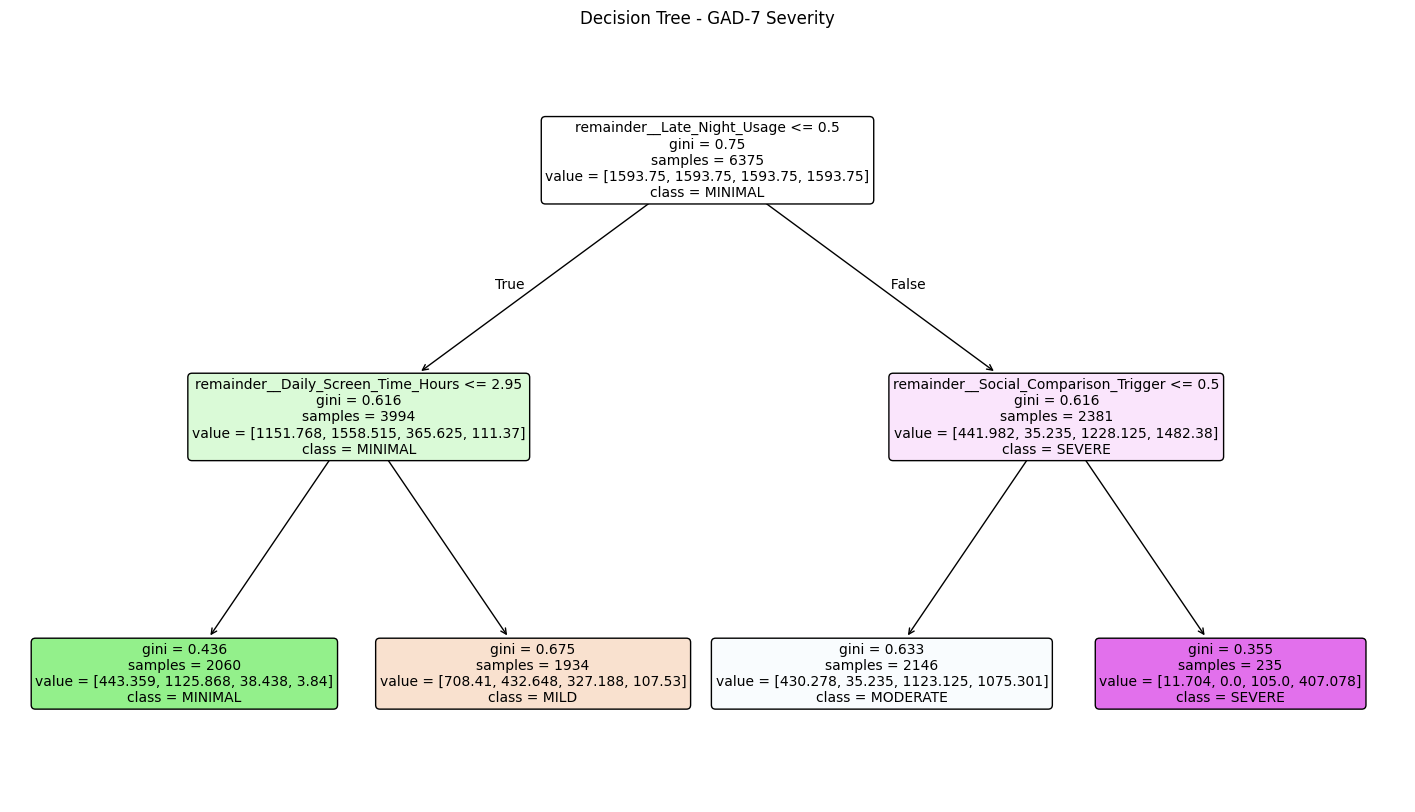

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Nombres finales de las variables después del One-Hot Encoding
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Árbol entrenado
tree_final = final_model.named_steps[
    "classifier"
]

plt.figure(figsize=(18, 10))

plot_tree(
    tree_final,
    feature_names=feature_names,
    class_names=tree_final.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - GAD-7 Severity")
plt.show()

In [ ]:
# Importancia de cada variable en el árbol
importances = final_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variable,Importancia
23,remainder__Late_Night_Usage,0.747322
22,remainder__Daily_Screen_Time_Hours,0.173065
24,remainder__Social_Comparison_Trigger,0.079613
2,cat__User_Archetype_AVERAGE USER,0.000000
4,cat__User_Archetype_HYPER-CONNECTED,0.000000
5,cat__User_Archetype_PASSIVE SCROLLER,0.000000
6,cat__Primary_Platform_FACEBOOK,0.000000
3,cat__User_Archetype_DIGITAL MINIMALIST,0.000000
0,cat__Gender_FEMALE,0.000000
1,cat__Gender_MALE,0.000000


Las variables que más influyeron en las decisiones del árbol fueron el uso nocturno de redes sociales, con aproximadamente un 75% de importancia, seguido del tiempo diario de pantalla con un 17% y la comparación social con un 8%. El resto de variables no fueron utilizadas por este árbol de profundidad 2

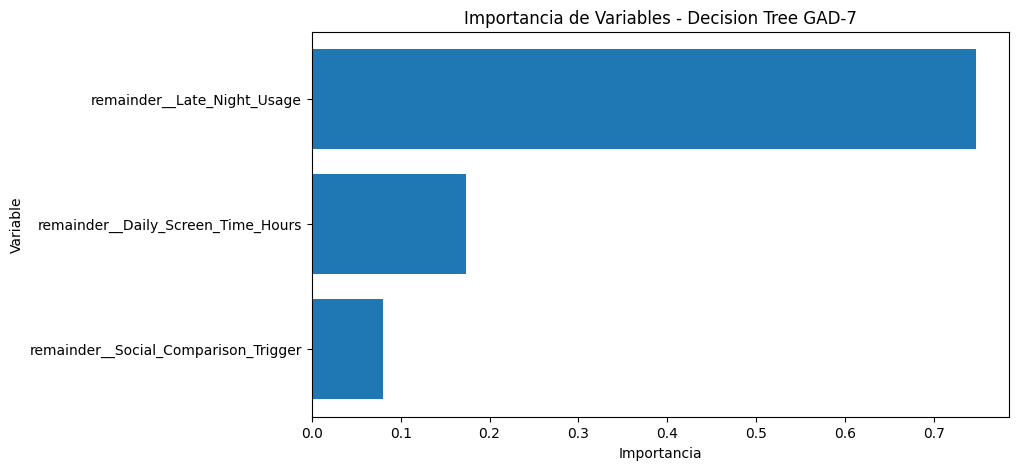

In [ ]:
# Nos quedamos con las variables que realmente utilizó el árbol
important_features = feature_importance[
    feature_importance["Importancia"] > 0
]

plt.figure(figsize=(9, 5))

plt.barh(
    important_features["Variable"],
    important_features["Importancia"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de Variables - Decision Tree GAD-7")

plt.show()

Nuestro objetivo fue predecir el nivel de severidad de ansiedad GAD-7 utilizando variables de comportamiento y uso de redes sociales. Como los datos ya estaban separados previamente en train y test, utilizamos el conjunto de entrenamiento para seleccionar la profundidad del árbol mediante validación cruzada de cinco folds. Probamos profundidades entre 2 y 10 y la profundidad 2 obtuvo el mejor F1 Macro promedio, aproximadamente 0.53.

Posteriormente entrenamos el modelo definitivo con todo el conjunto de entrenamiento y lo evaluamos sobre el test, obteniendo un accuracy del 57.15% y un F1 Macro de 0.53. El modelo tuvo mayor facilidad para identificar las categorías Minimal y Moderate y más dificultad con Mild y especialmente Severe.

Finalmente, al interpretar el árbol encontramos que las tres variables utilizadas fueron Late Night Usage, Daily Screen Time y Social Comparison Trigger, siendo el uso nocturno la variable con mayor importancia.

In [ ]:
# ==========================================
# MODELO 2: PHQ-9 SEVERITY
# ==========================================

# Target
y_train_phq = train_df["PHQ_9_Severity"]
y_test_phq = test_df["PHQ_9_Severity"]


columnas_eliminar_phq = [
    "User_ID",
    "PHQ_9_Severity",
    "PHQ_9_Score",
    "GAD_7_Score",
    "GAD_7_Severity"
]

X_train_phq = train_df.drop(columns=columnas_eliminar_phq)
X_test_phq = test_df.drop(columns=columnas_eliminar_phq)

print("X_train PHQ:", X_train_phq.shape)
print("X_test PHQ:", X_test_phq.shape)

print("\nDistribución PHQ TRAIN:")
print(y_train_phq.value_counts())

print("\nDistribución PHQ TEST:")
print(y_test_phq.value_counts())

X_train PHQ: (6375, 10)
X_test PHQ: (1608, 10)

Distribución PHQ TRAIN:
PHQ_9_Severity
NONE-MINIMAL         3179
MILD                 1882
MODERATE             1018
MODERATELY SEVERE     278
SEVERE                 18
Name: count, dtype: int64

Distribución PHQ TEST:
PHQ_9_Severity
NONE-MINIMAL         777
MILD                 476
MODERATE             273
MODERATELY SEVERE     78
SEVERE                 4
Name: count, dtype: int64


In [ ]:
categorical_features_phq = X_train_phq.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables categóricas PHQ:")
print(categorical_features_phq)

Variables categóricas PHQ:
['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_phq = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_phq
        )
    ],
    remainder="passthrough"
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

resultados_cv_phq = []

for profundidad in [2, 3, 4, 5, 6, 7, 8, 10]:

    tree_cv_phq = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=46,
        class_weight="balanced"
    )

    model_cv_phq = Pipeline(
        steps=[
            ("preprocessor", preprocessor_phq),
            ("classifier", tree_cv_phq)
        ]
    )

    scores = cross_val_score(
        model_cv_phq,
        X_train_phq,
        y_train_phq,
        cv=5,
        scoring="f1_macro"
    )

    resultados_cv_phq.append({
        "max_depth": profundidad,
        "f1_macro_promedio": scores.mean(),
        "desviacion": scores.std()
    })

resultados_cv_phq_df = pd.DataFrame(resultados_cv_phq)

resultados_cv_phq_df

,max_depth,f1_macro_promedio,desviacion
0,2,0.297072,0.011967
1,3,0.308258,0.009930
2,4,0.309913,0.022898
3,5,0.315995,0.024621
4,6,0.314200,0.018527
5,7,0.319732,0.015291
6,8,0.323850,0.013956
7,10,0.319494,0.012904


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

final_tree_phq = DecisionTreeClassifier(
    max_depth=8,
    random_state=46,
    class_weight="balanced"
)

final_model_phq = Pipeline(
    steps=[
        ("preprocessor", preprocessor_phq),
        ("classifier", final_tree_phq)
    ]
)

# Entrenar SOLO con TRAIN
final_model_phq.fit(X_train_phq, y_train_phq)

# Ahora sí usamos TEST para la evaluación final
y_pred_phq = final_model_phq.predict(X_test_phq)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

accuracy_phq = accuracy_score(
    y_test_phq,
    y_pred_phq
)

f1_macro_phq = f1_score(
    y_test_phq,
    y_pred_phq,
    average="macro"
)

print(f"Accuracy PHQ-9: {accuracy_phq:.4f}")
print(f"Accuracy PHQ-9 (%): {accuracy_phq * 100:.2f}%")
print(f"F1 Macro PHQ-9: {f1_macro_phq:.4f}")

print("\nClassification Report PHQ-9:")
print(
    classification_report(
        y_test_phq,
        y_pred_phq,
        zero_division=0
    )
)

Accuracy PHQ-9: 0.4876
Accuracy PHQ-9 (%): 48.76%
F1 Macro PHQ-9: 0.3100

Classification Report PHQ-9:
                   precision    recall  f1-score   support

             MILD       0.37      0.25      0.30       476
         MODERATE       0.34      0.26      0.30       273
MODERATELY SEVERE       0.13      0.40      0.20        78
     NONE-MINIMAL       0.77      0.73      0.75       777
           SEVERE       0.01      0.25      0.02         4

         accuracy                           0.49      1608
        macro avg       0.32      0.38      0.31      1608
     weighted avg       0.55      0.49      0.51      1608



Para PHQ-9, el modelo obtuvo un accuracy del 48.76% y un F1 Macro de 0.31. El rendimiento fue considerablemente inferior al modelo GAD-7. Además, existe un fuerte desbalance entre las categorías, especialmente en Severe, que cuenta únicamente con cuatro observaciones en el conjunto de test. Por esta razón, utilizamos principalmente F1 Macro para evaluar el rendimiento entre todas las categorías

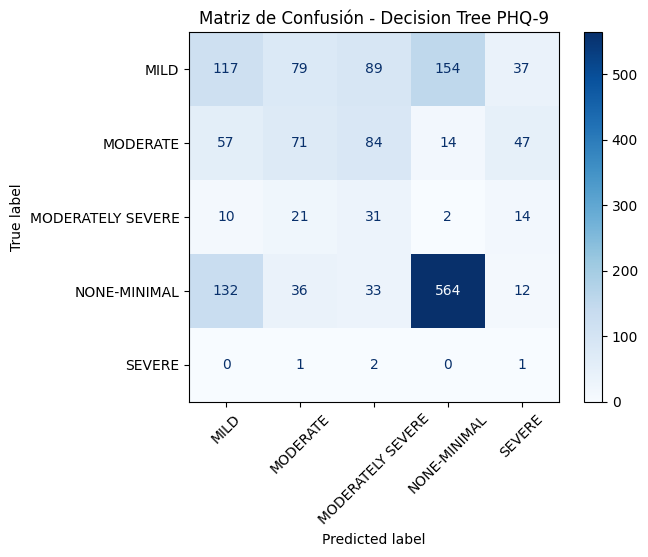

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_phq,
    y_pred_phq,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Matriz de Confusión - Decision Tree PHQ-9")
plt.show()

La matriz de confusión muestra que el modelo PHQ-9 identifica principalmente la categoría None-Minimal, pero presenta una alta confusión entre las categorías Mild, Moderate y Moderately Severe. La clase Severe está muy poco representada, con solo cuatro casos en test, por lo que su evaluación no es estable. Esto explica el F1 Macro relativamente bajo del modelo

In [ ]:
# Nombres de variables después del preprocesamiento
feature_names_phq = final_model_phq.named_steps[
    "preprocessor"
].get_feature_names_out()

# Importancias del árbol
importances_phq = final_model_phq.named_steps[
    "classifier"
].feature_importances_

# Tabla
feature_importance_phq = pd.DataFrame({
    "Variable": feature_names_phq,
    "Importancia": importances_phq
}).sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_phq.head(10)

,Variable,Importancia
23,remainder__Late_Night_Usage,0.329709
22,remainder__Daily_Screen_Time_Hours,0.291016
25,remainder__Sleep_Duration_Hours,0.151761
13,cat__Dominant_Content_Type_EDUCATIONAL/TECH,0.042624
21,remainder__Age,0.036956
9,cat__Primary_Platform_SNAPCHAT,0.026630
1,cat__Gender_MALE,0.023318
19,cat__Activity_Type_ACTIVE,0.020554
17,cat__Dominant_Content_Type_NEWS/POLITICS,0.010844
4,cat__User_Archetype_HYPER-CONNECTED,0.009930


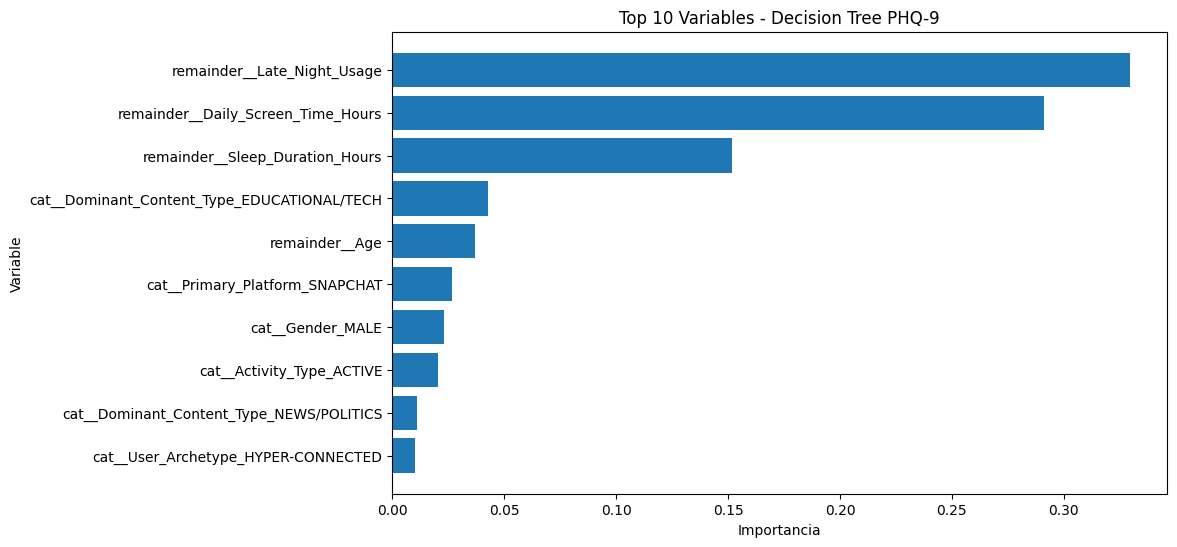

In [ ]:
top10_phq = feature_importance_phq.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_phq["Variable"],
    top10_phq["Importancia"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 Variables - Decision Tree PHQ-9")

plt.show()

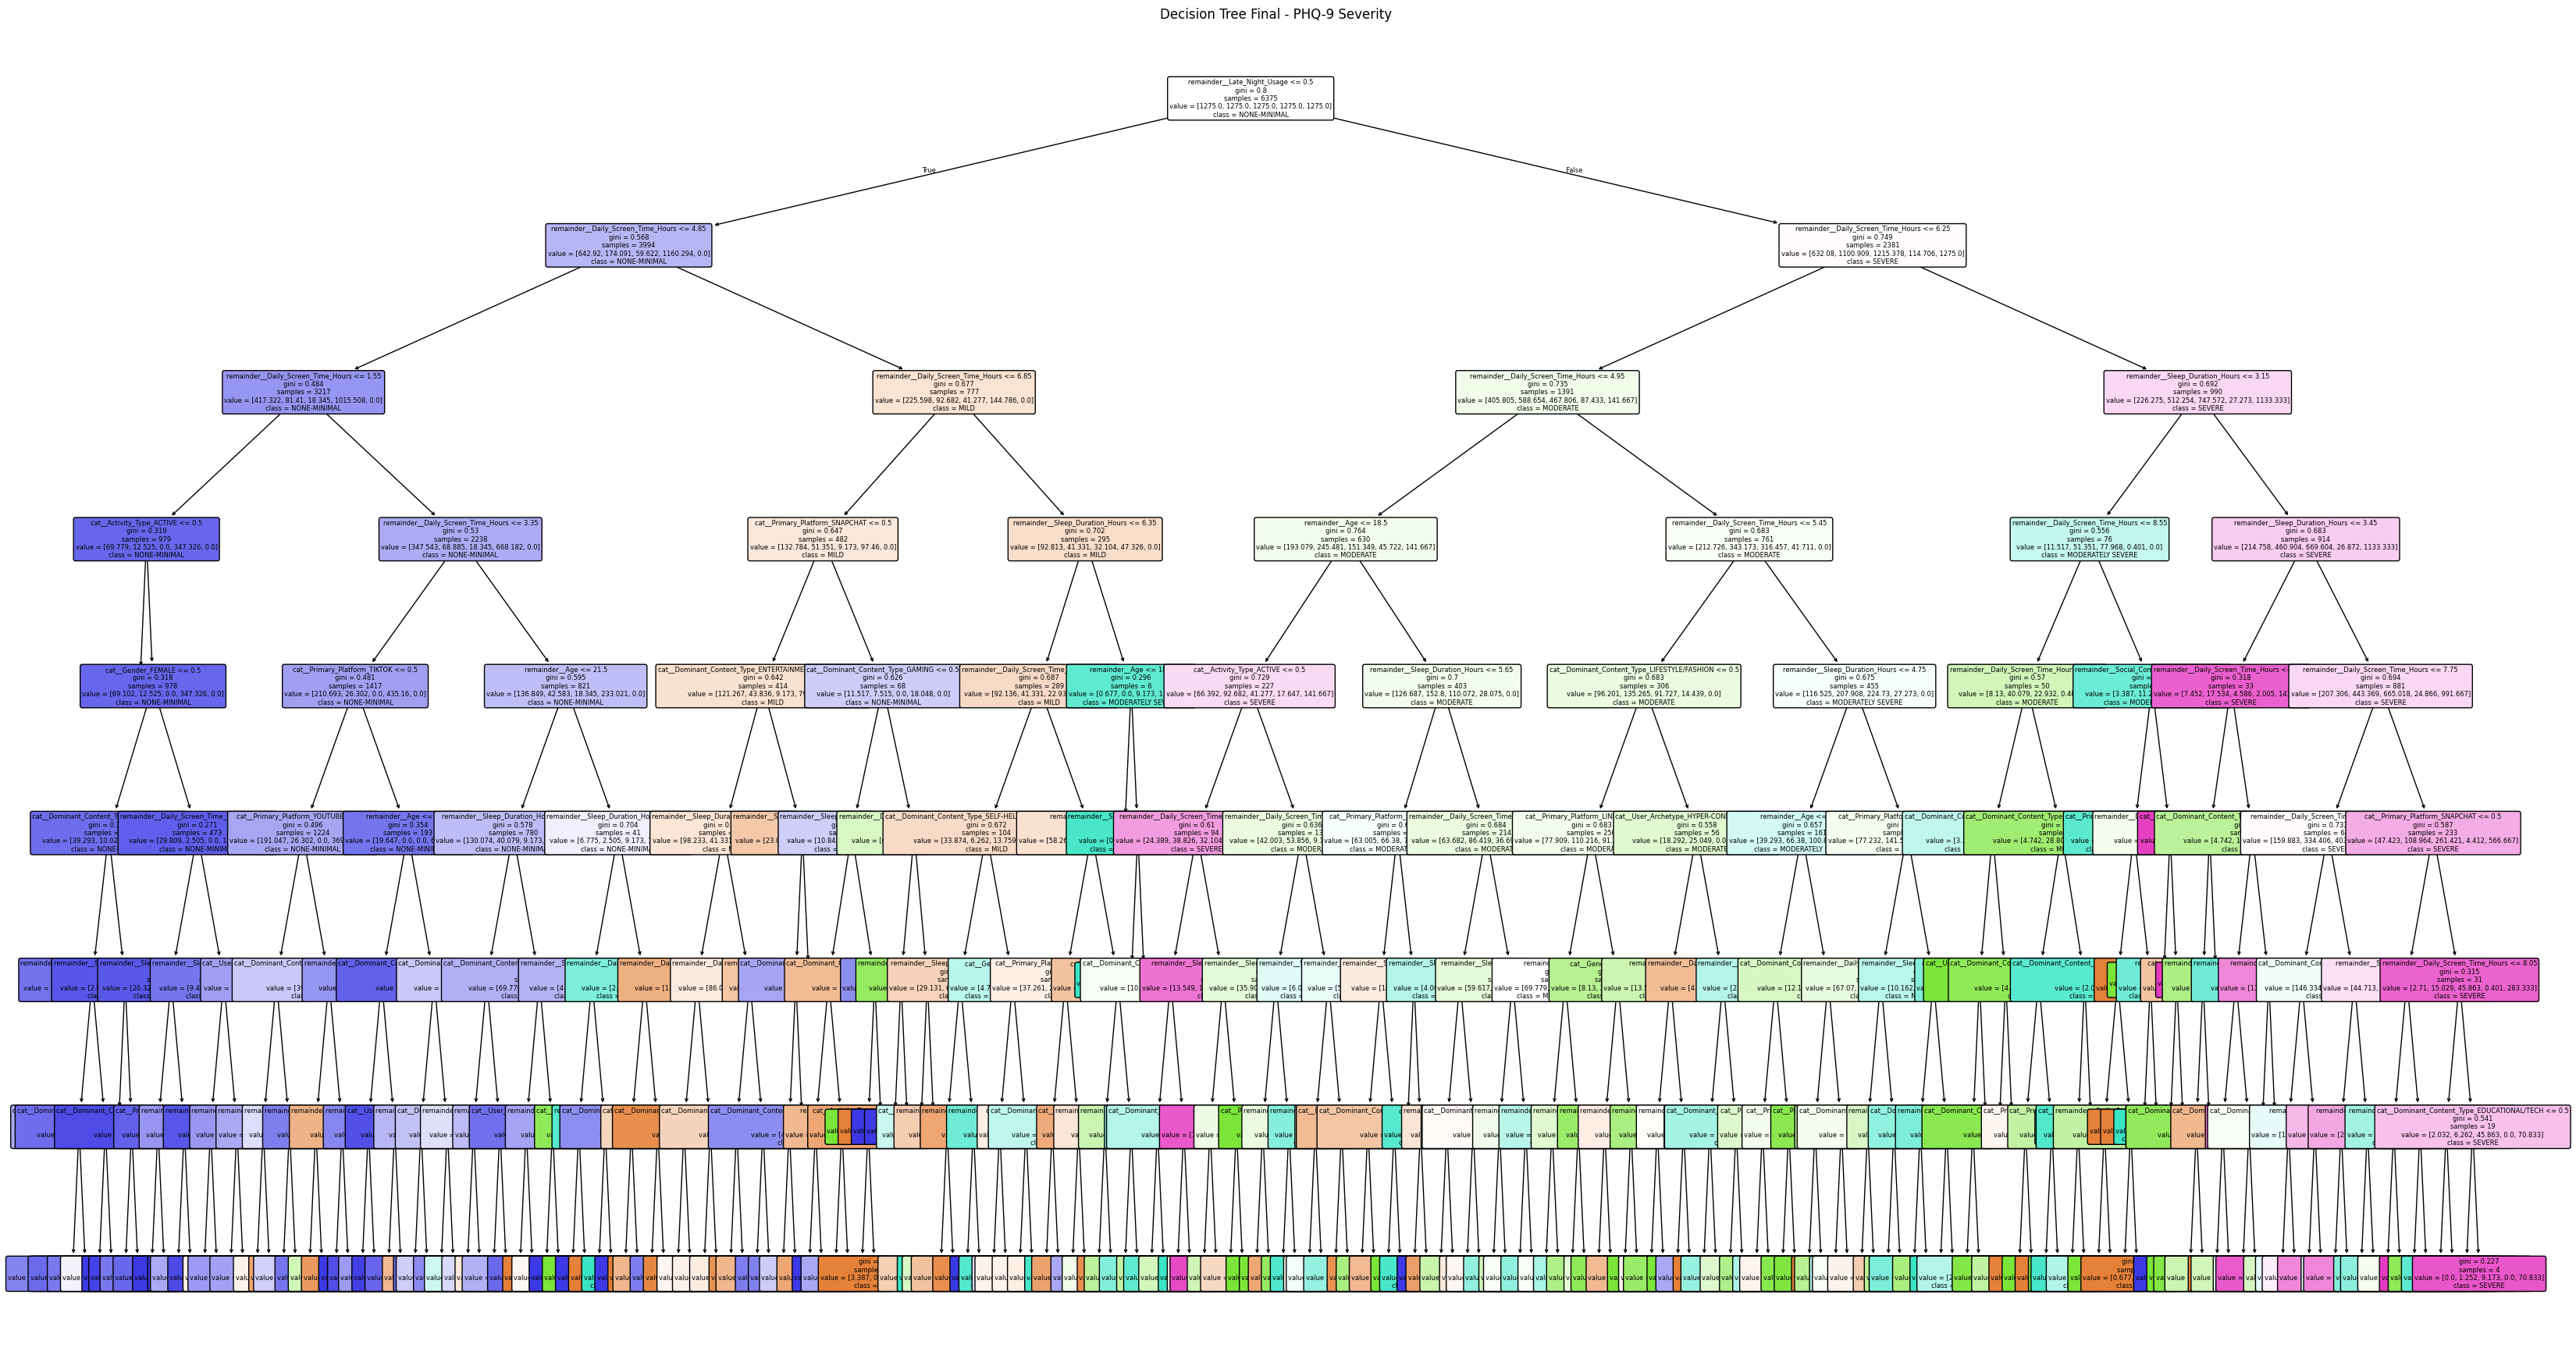

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Obtener nombres de variables después del preprocesamiento
feature_names_phq = final_model_phq.named_steps[
    "preprocessor"
].get_feature_names_out()

# Obtener el árbol entrenado
tree_phq_final = final_model_phq.named_steps[
    "classifier"
]

# Dibujar el árbol completo
plt.figure(figsize=(40, 22))

plot_tree(
    tree_phq_final,
    feature_names=feature_names_phq,
    class_names=tree_phq_final.classes_,
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Decision Tree Final - PHQ-9 Severity")
plt.show()

Los modelos muestran que los patrones de uso de redes sociales tienen capacidad predictiva sobre los niveles de salud mental analizados. El uso nocturno y el tiempo diario de pantalla fueron las variables más relevantes en ambos modelos.

Para GAD-7, el uso nocturno fue la variable dominante (75%), seguido del tiempo de pantalla (17%) y la comparación social (8%). El modelo alcanzó un F1 Macro de 0.53.

Para PHQ-9, las variables más relevantes fueron el uso nocturno (33%), el tiempo de pantalla (29%) y la duración del sueño (15%). Sin embargo, su capacidad predictiva fue menor (F1 Macro 0.31), especialmente en las categorías de mayor severidad.

En conjunto, GAD-7 resultó más predecible que PHQ-9 con las variables disponibles. Los resultados sugieren una asociación entre determinados patrones de uso digital y los niveles de ansiedad y síntomas depresivos, sin implicar una relación causal.